# ETAPE 0 & 1 — Préparation & Compréhension des données
**Projet : Optimisation du Réseau de Boutiques TELECOM — Groupe 5 SUD-EST**

---
## Objectif
- Charger et inspecter les 4 fichiers sources
- Comprendre la structure, les types et le sens de chaque variable
- Vérifier la clé de jointure `ORDER_SHOP_CD`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 40)

DATA_PATH = '.'  # tous les fichiers sont dans le même dossier

## 0.1 Chargement des fichiers

In [2]:
# --- Fichier principal (3.2M lignes) ---
df_raw = pd.read_csv('Fichier_Principal_pedago_anonym.csv', low_memory=False)
print(f"Fichier_principal : {df_raw.shape[0]:,} lignes x {df_raw.shape[1]} colonnes")

# --- Coordonnées boutiques ---
coord = pd.read_csv('COORD_BQT.csv')
print(f"COORD_BQT        : {coord.shape[0]} lignes x {coord.shape[1]} colonnes")

# --- Libellés boutiques ---
lib = pd.read_csv('LIB_BQT.csv')
print(f"LIB_BQT          : {lib.shape[0]} lignes x {lib.shape[1]} colonnes")

Fichier_principal : 3,258,114 lignes x 13 colonnes
COORD_BQT        : 1042 lignes x 5 colonnes
LIB_BQT          : 3435 lignes x 2 colonnes


## 1.1 Structure du fichier principal

In [3]:
df_raw.head(5)

,LINE_TYPE,PERIOD_YYYY,PERIOD_MM,ORDER_SHOP_CD,PERSON_SALUTATION_CD,PERSON_BIRTH_DT_year,NET_ZONE_IN,DENSE_ZONE_IN,DEPRTMNT_ID,CITY_LN,ZONE,Geolife,GEOLIFE_AGG
0,T,2022,12,ONEESHOP,MME,1960-1969,123.0,2.0,30,LAVAL PRADEL,6_SUD,09A_famille,Rural ouvrier
1,T,2022,12,77130FJ9-1,M,1980-1989,123.0,2.0,77,MAROLLES SUR SEINE,1_IDF_77_91_94_78_,08C_famille active,Rural dynamique
2,T,2021,11,89000FM9-4,MLE,1980-1989,0.0,0.0,89,SOUMAINTRAIN,3_EST,10A_agricole,Rural traditionnel
3,I,2022,11,CCNDFFID,M,1980-1989,2.0,2.0,41,SAMBIN,9_NORMANDIE_CENTRE,10B_isole,Rural traditionnel
4,T,2022,11,VADPCM,M,1980-1989,0.0,0.0,20,ROSAZIA,5_SUD_EST,11A_saisonnier,Résidence secondaire


In [4]:
# Types et nulls
info = pd.DataFrame({
    'Type': df_raw.dtypes,
    'Nulls': df_raw.isnull().sum(),
    '% Nulls': (df_raw.isnull().sum() / len(df_raw) * 100).round(2),
    'Uniques': df_raw.nunique()
})
info

,Type,Nulls,% Nulls,Uniques
LINE_TYPE,str,0,0.00,3
PERIOD_YYYY,int64,0,0.00,2
PERIOD_MM,int64,0,0.00,3
ORDER_SHOP_CD,str,0,0.00,2711
PERSON_SALUTATION_CD,str,149588,4.59,41
PERSON_BIRTH_DT_year,str,176805,5.43,12
NET_ZONE_IN,float64,48715,1.50,9
DENSE_ZONE_IN,float64,48715,1.50,6
DEPRTMNT_ID,str,0,0.00,106
CITY_LN,str,472,0.01,30275


In [5]:
# Dictionnaire métier des colonnes
dico = pd.DataFrame([
    ['LINE_TYPE',            'Categ.',  'Type de produit vendu (T=mobile, B=box, F=fixe...)'],
    ['PERIOD_YYYY',          'Num.',    'Année de l\'acquisition'],
    ['PERIOD_MM',            'Num.',    'Mois de l\'acquisition'],
    ['ORDER_SHOP_CD',        'ID',      'Code boutique — CLE DE JOINTURE'],
    ['PERSON_SALUTATION_CD', 'Categ.',  'Civilité client (M/MME)'],
    ['PERSON_BIRTH_DT_year', 'Texte',   'Décennie de naissance (ex: 1970-1979)'],
    ['NET_ZONE_IN',          'Num.',    'Zone réseau'],
    ['DENSE_ZONE_IN',        'Num.',    'Zone de densité'],
    ['DEPRTMNT_ID',          'Num.',    'Département du client'],
    ['CITY_LN',              'Texte',   'Ville du client'],
    ['ZONE',                 'Categ.',  'Zone commerciale — FILTRER sur 5_SUD_EST'],
    ['Geolife',              'Categ.',  'Segment socio-démographique client'],
    ['GEOLIFE_AGG',          'Categ.',  'Segment Geolife agrégé'],
], columns=['Variable', 'Type', 'Description'])
dico

,Variable,Type,Description
0,LINE_TYPE,Categ.,"Type de produit vendu (T=mobile, B=b..."
1,PERIOD_YYYY,Num.,Année de l'acquisition
2,PERIOD_MM,Num.,Mois de l'acquisition
3,ORDER_SHOP_CD,ID,Code boutique — CLE DE JOINTURE
4,PERSON_SALUTATION_CD,Categ.,Civilité client (M/MME)
5,PERSON_BIRTH_DT_year,Texte,Décennie de naissance (ex: 1970-1979)
6,NET_ZONE_IN,Num.,Zone réseau
7,DENSE_ZONE_IN,Num.,Zone de densité
8,DEPRTMNT_ID,Num.,Département du client
9,CITY_LN,Texte,Ville du client


## 1.2 Structure des tables secondaires

In [6]:
print("=== COORD_BQT ===")
print(coord.dtypes)
print()
coord.head(3)

=== COORD_BQT ===
ORDER_SHOP_CD          str
Surface_COMMERC    float64
Emplacement_PDV        str
Coord_L2E_II_X     float64
Coord_L2E_II_Y     float64
dtype: object



,ORDER_SHOP_CD,Surface_COMMERC,Emplacement_PDV,Coord_L2E_II_X,Coord_L2E_II_Y
0,95PHSEERMO,110.0,CC,593302.0,2443396.0
1,67700FF5-4,84.0,CV,969415.0,2427885.0
2,16017FL9-3,163.0,CV,432042.0,2078600.0


In [7]:
print("=== LIB_BQT ===")
print(lib.dtypes)
print()
lib.head(3)

=== LIB_BQT ===
ORDER_SHOP_CD    str
MKT_CHANNL_LB    str
dtype: object



,ORDER_SHOP_CD,MKT_CHANNL_LB
0,61ACTEMACE,Réseau Concurrentiel
1,26200FK7-7,Agence Distribution
2,64PHSEOLOR,Réseau Partenaire


## 1.3 Vérification de la clé de jointure ORDER_SHOP_CD

In [8]:
# Boutiques uniques dans chaque table
shops_principal = set(df_raw['ORDER_SHOP_CD'].unique())
shops_coord     = set(coord['ORDER_SHOP_CD'].unique())
shops_lib       = set(lib['ORDER_SHOP_CD'].unique())

print(f"Boutiques uniques Fichier_principal : {len(shops_principal):,}")
print(f"Boutiques uniques COORD_BQT         : {len(shops_coord)}")
print(f"Boutiques uniques LIB_BQT           : {len(shops_lib)}")
print()
print(f"Boutiques principal sans coord      : {len(shops_principal - shops_coord)}")
print(f"Boutiques principal sans lib        : {len(shops_principal - shops_lib)}")
print(f"Boutiques coord sans lib            : {len(shops_coord - shops_lib)}")

Boutiques uniques Fichier_principal : 2,711
Boutiques uniques COORD_BQT         : 1042
Boutiques uniques LIB_BQT           : 3435

Boutiques principal sans coord      : 1730
Boutiques principal sans lib        : 1028
Boutiques coord sans lib            : 11


## 1.4 Distribution des ZONES

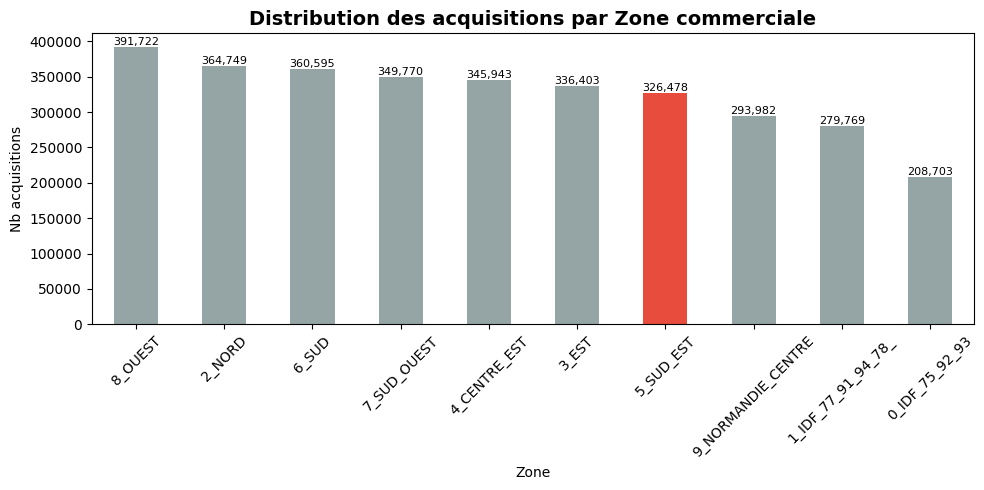


SUD-EST représente 10.0% des acquisitions nationales


In [9]:
zone_counts = df_raw['ZONE'].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if z == '5_SUD_EST' else '#95a5a6' for z in zone_counts.index]
zone_counts.plot(kind='bar', ax=ax, color=colors)
ax.set_title('Distribution des acquisitions par Zone commerciale', fontsize=14, fontweight='bold')
ax.set_xlabel('Zone')
ax.set_ylabel('Nb acquisitions')
ax.tick_params(axis='x', rotation=45)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('zone_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nSUD-EST représente {zone_counts['5_SUD_EST'] / zone_counts.sum() * 100:.1f}% des acquisitions nationales")

In [10]:
# Aperçu LINE_TYPE national
print("Types de produits (national) :")
print(df_raw['LINE_TYPE'].value_counts())
print()
print("Années disponibles :")
print(sorted(df_raw['PERIOD_YYYY'].unique()))
print()
print("Emplacement boutiques (COORD_BQT) :")
print(coord['Emplacement_PDV'].value_counts())

Types de produits (national) :
LINE_TYPE
T    1401690
M    1027994
I     828430
Name: count, dtype: int64

Années disponibles :
[np.int64(2021), np.int64(2022)]

Emplacement boutiques (COORD_BQT) :
Emplacement_PDV
CV               541
CC               498
Hors CV et CC      1
Name: count, dtype: int64


## Conclusion Etape 0-1

| Constat | Valeur |
|---|---|
| Fichier principal | 3.2M lignes, 13 colonnes |
| Zone SUD-EST | ~326K acquisitions |
| Période | Colonnes PERIOD_YYYY + PERIOD_MM (déjà séparées) |
| Coordonnées | Format Lambert II Etendu (à convertir en lat/lon) |
| Décennie naissance | Format texte '1970-1979' (à traiter) |
| Clé jointure | ORDER_SHOP_CD présente dans les 3 tables |

**→ Prochaine étape : Nettoyage (Etape 2)**